## What is a Regression Plot?

A regression plot visualizes the relationship between variables by fitting a regression model and drawing its line/curve on a scatter plot.

Used to:

- visualize trends

- detect linear / nonlinear relationships

- check residual behavior

- validate assumptions

- compare models

### PART 1 — Basic Linear Regression Plot (Seaborn)

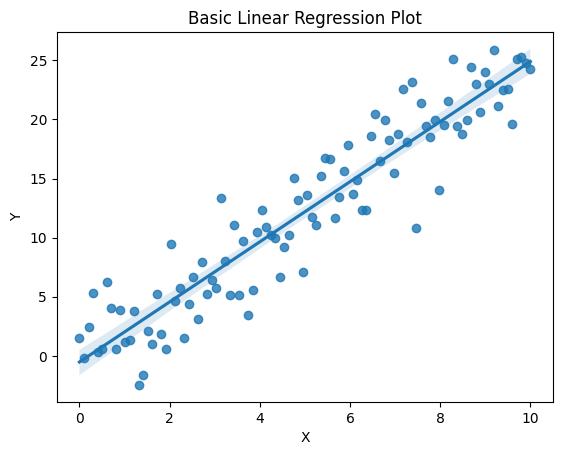

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 2.5 * x + np.random.normal(0, 3, 100)

df = pd.DataFrame({"X": x, "Y": y})

sns.regplot(x="X", y="Y", data=df)
plt.title("Basic Linear Regression Plot")
plt.show()


### PART 2 — Regression Plot Without Confidence Interval

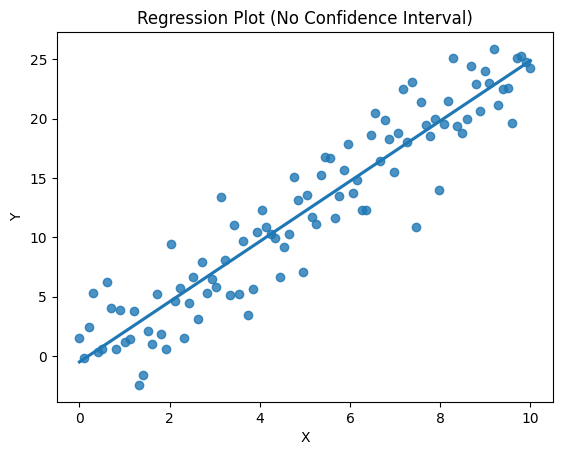

In [2]:
sns.regplot(x="X", y="Y", data=df, ci=None)
plt.title("Regression Plot (No Confidence Interval)")
plt.show()


### PART 3 — Polynomial Regression Plot

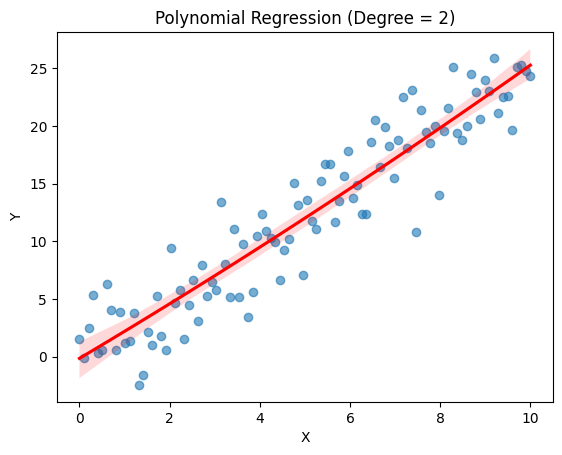

In [3]:
sns.regplot(
    x="X",
    y="Y",
    data=df,
    order=2,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Polynomial Regression (Degree = 2)")
plt.show()


### PART 4 — Regression with Custom Styling

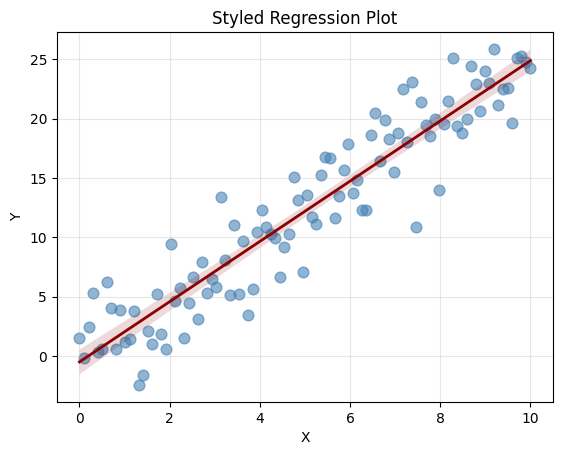

In [4]:
sns.regplot(
    x="X",
    y="Y",
    data=df,
    scatter_kws={"s": 60, "alpha": 0.6, "color": "steelblue"},
    line_kws={"color": "darkred", "linewidth": 2}
)

plt.title("Styled Regression Plot")
plt.grid(alpha=0.3)
plt.show()


### PART 5 — Regression Plot with Hue (Categorical Groups)

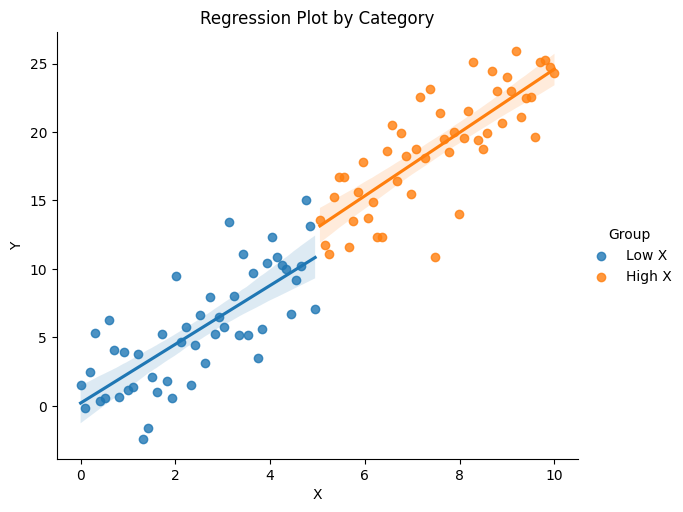

In [5]:
df["Group"] = np.where(df["X"] > 5, "High X", "Low X")

sns.lmplot(
    x="X",
    y="Y",
    hue="Group",
    data=df,
    height=5,
    aspect=1.2
)

plt.title("Regression Plot by Category")
plt.show()


### PART 6 — Multiple Regression Lines (Subplots)

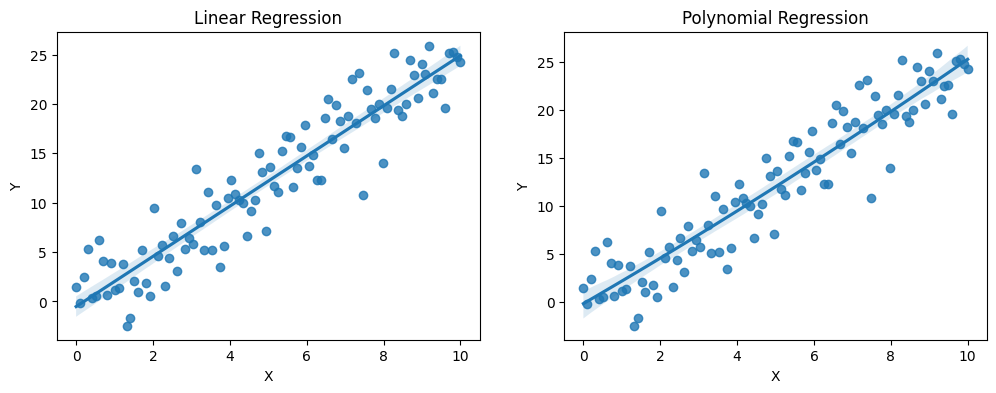

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(x="X", y="Y", data=df, ax=axes[0])
sns.regplot(x="X", y="Y", data=df, order=2, ax=axes[1])

axes[0].set_title("Linear Regression")
axes[1].set_title("Polynomial Regression")

plt.show()


### PART 7 — Robust Regression (Outlier Resistant)

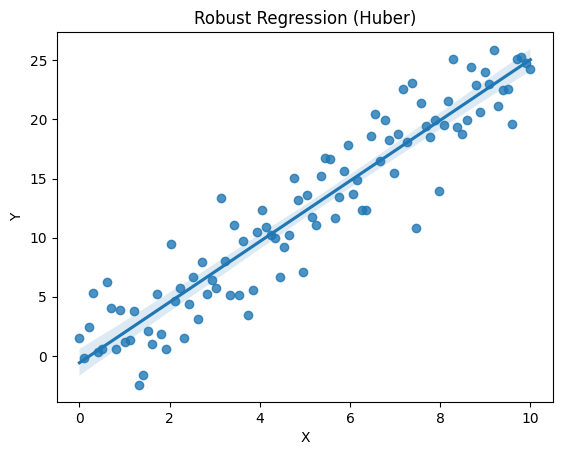

In [7]:
sns.regplot(
    x="X",
    y="Y",
    data=df,
    robust=True
)

plt.title("Robust Regression (Huber)")
plt.show()


### PART 8 — Logistic Regression Plot (Binary Target)

c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\NIL\Desktop\gee\DataAnalysis\.venv\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\N

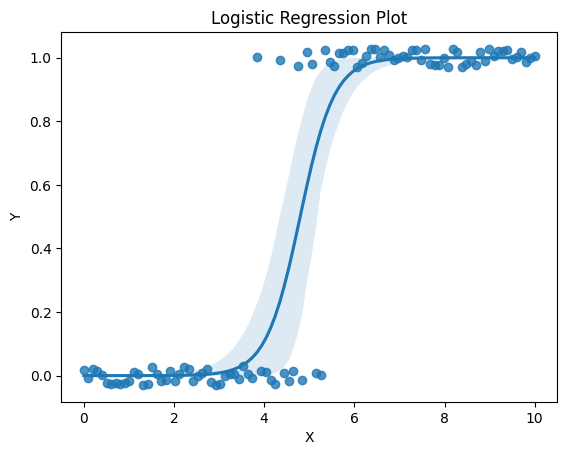

In [8]:
np.random.seed(1)

x = np.linspace(0, 10, 100)
y = (x + np.random.normal(0, 1, 100)) > 5
df_bin = pd.DataFrame({"X": x, "Y": y.astype(int)})

sns.regplot(
    x="X",
    y="Y",
    data=df_bin,
    logistic=True,
    y_jitter=0.03
)

plt.title("Logistic Regression Plot")
plt.show()


### PART 9 — LOWESS / LOESS Regression (Non-parametric)

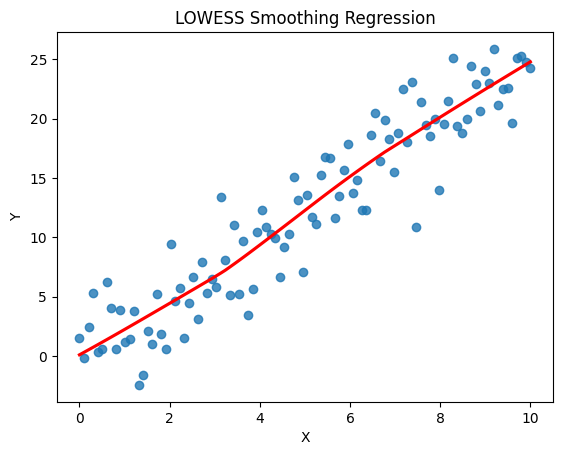

In [9]:
sns.regplot(
    x="X",
    y="Y",
    data=df,
    lowess=True,
    line_kws={"color": "red"}
)

plt.title("LOWESS Smoothing Regression")
plt.show()


### PART 10 — Regression with Confidence Bands Removed or Styled

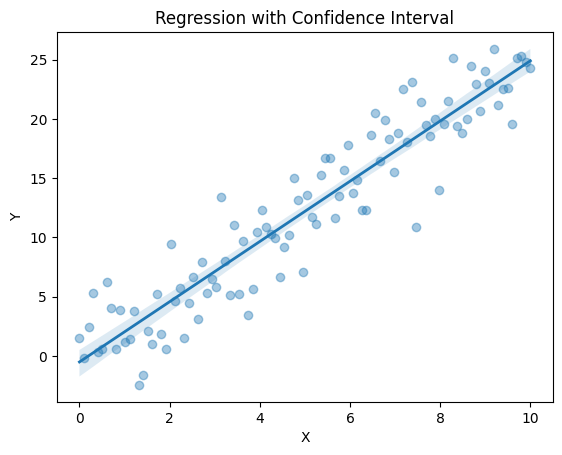

In [10]:
sns.regplot(
    x="X",
    y="Y",
    data=df,
    ci=95,
    line_kws={"linewidth": 2},
    scatter_kws={"alpha": 0.4}
)
plt.title("Regression with Confidence Interval")
plt.show()


### PART 11 — Regression Residual Plot

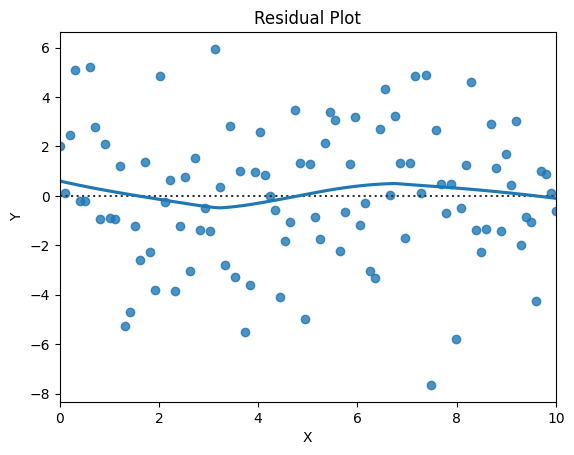

In [11]:
sns.residplot(
    x="X",
    y="Y",
    data=df,
    lowess=True
)

plt.title("Residual Plot")
plt.show()


### PART 12 — Multiple Regression (using statsmodels)

In [12]:
import statsmodels.api as sm

X = df[["X"]]
X = sm.add_constant(X)
y = df["Y"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     733.7
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           2.65e-47
Time:                        23:21:24   Log-Likelihood:                -241.52
No. Observations:                 100   AIC:                             487.0
Df Residuals:                      98   BIC:                             492.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5184      0.543     -0.955      0.3

### PART 13 — Regression Line from Scratch (Manual)

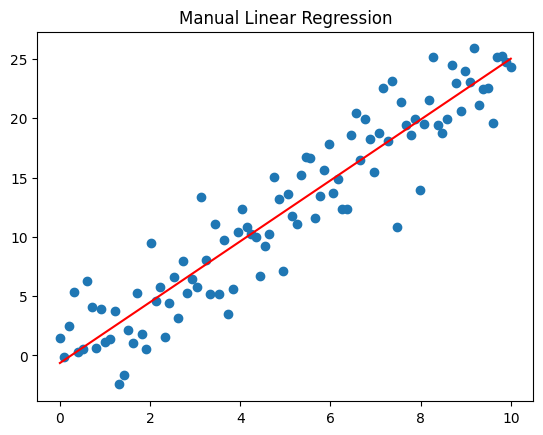

In [13]:
# Manual least squares
x_vals = df["X"].values
y_vals = df["Y"].values

m = np.cov(x_vals, y_vals)[0, 1] / np.var(x_vals)
b = y_vals.mean() - m * x_vals.mean()

plt.scatter(x_vals, y_vals)
plt.plot(x_vals, m * x_vals + b, color="red")
plt.title("Manual Linear Regression")
plt.show()


### PART 14 — Interactive Regression Plot (Plotly)

In [14]:
import plotly.express as px

fig = px.scatter(
    df, x="X", y="Y", trendline="ols",
    title="Interactive Regression Plot"
)

fig.show()


### PART 15 — Reusable Regression Plot Function


In [15]:
def regression_plot(
    df, x, y,
    method="linear",
    hue=None,
    order=2
):
    if method == "linear":
        sns.regplot(x=x, y=y, data=df)

    elif method == "poly":
        sns.regplot(x=x, y=y, data=df, order=order)

    elif method == "lowess":
        sns.regplot(x=x, y=y, data=df, lowess=True)

    elif method == "logistic":
        sns.regplot(x=x, y=y, data=df, logistic=True)

    plt.title(f"Regression Plot ({method})")
    plt.show()


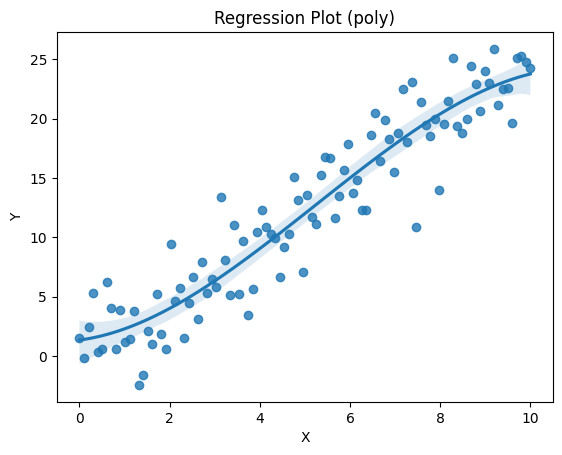

In [16]:
regression_plot(df, "X", "Y", method="poly", order=3)
